In [1]:
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
)
analysis_run = ds.pipeline.open(label="docs_default")
marker_ref = analysis_run["markers"]

ds

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'RNA_clusters', 
            'RNA_percentMito', 'RNA_percentRibo', 'RNA_nFeatures', 'clusters_coarse', 'RNA_nCounts', 
            'RNA_UMAP2', 'S_score', 'RNA_leiden_cluster', 'RNA_UMAP1', 'clusters', 
          
   RNA assay has 27998 features and following metadata:
            'I', 'ids', 'names', 'highly_variable_genes', 'nCells', 
            'dropOuts'

In [3]:
cluster_values = analysis_run.cells.fetch("clusters")
pd.Series(cluster_values).value_counts().sort_index()

1     367
2     512
3     461
4     236
5     349
6     199
7     145
8     222
9     377
10     93
11    540
12    195
Name: count, dtype: int64

In [4]:
ds.show_zarr_tree(depth=1)

/
├── RNA
│   ├── artifacts
│   ├── countSummaries
│   ├── counts (3696, 27998) uint16
│   ├── countsT (27998, 3696) uint16
│   └── featureData
├── artifacts
│   ├── cell_selection
│   └── metadata_snapshot
├── cellData
│   ├── G2M_score (3696,) float32
│   ├── I (3696,) bool
│   ├── RNA_UMAP1 (3696,) float32
│   ├── RNA_UMAP2 (3696,) float32
│   ├── RNA_clusters (3696,) int64
│   ├── RNA_leiden_cluster (3696,) int64
│   ├── RNA_nCounts (3696,) float64
│   ├── RNA_nFeatures (3696,) float64
│   ├── RNA_percentMito (3696,) float64
│   ├── RNA_percentRibo (3696,) float64
│   ├── S_score (3696,) float32
│   ├── clusters (3696,) <U13
│   ├── clusters_coarse (3696,) <U13
│   ├── ids (3696,) <U16
│   └── names (3696,) <U16
└── pipeline
    └── runs



In [5]:
ds.show_zarr_tree(start="cellData")

/cellData
├── G2M_score (3696,) float32
├── I (3696,) bool
├── RNA_UMAP1 (3696,) float32
├── RNA_UMAP2 (3696,) float32
├── RNA_clusters (3696,) int64
├── RNA_leiden_cluster (3696,) int64
├── RNA_nCounts (3696,) float64
├── RNA_nFeatures (3696,) float64
├── RNA_percentMito (3696,) float64
├── RNA_percentRibo (3696,) float64
├── S_score (3696,) float32
├── clusters (3696,) <U13
├── clusters_coarse (3696,) <U13
├── ids (3696,) <U16
└── names (3696,) <U16

  names: shape=(3696,), dtype=<U16, chunks=(100000,)
  G2M_score: shape=(3696,), dtype=float32, chunks=(100000,)
  RNA_percentMito: shape=(3696,), dtype=float64, chunks=(100000,)
  I: shape=(3696,), dtype=bool, chunks=(100000,)
  RNA_clusters: shape=(3696,), dtype=int64, chunks=(100000,)
  RNA_nFeatures: shape=(3696,), dtype=float64, chunks=(100000,)
  RNA_leiden_cluster: shape=(3696,), dtype=int64, chunks=(100000,)
  ids: shape=(3696,), dtype=<U16, chunks=(100000,)
  RNA_percentRibo: shape=(3696,), dtype=float64, chunks=(100000,)
  clus

In [6]:
ds.cells.to_pandas_dataframe(["I"])["I"].value_counts()

I
True    3696
Name: count, dtype: int64

In [7]:
ds.show_zarr_tree(start="RNA", depth=1)

/RNA
├── artifacts
│   ├── ann_index
│   ├── cluster_labels
│   ├── cluster_selection
│   ├── connectivity_map
│   ├── embedding
│   ├── embedding_initialization
│   ├── feature_scaling
│   ├── feature_selection
│   ├── feature_summary
│   ├── marker_table
│   ├── metadata_snapshot
│   ├── neighbors
│   ├── normalized
│   └── reduction
├── countSummaries
│   ├── columnPositive (27998,) int64
│   ├── rowPositive (3696,) int64
│   └── rowSums (3696,) float64
├── counts (3696, 27998) uint16
├── countsT (27998, 3696) uint16
└── featureData
    ├── I (27998,) bool
    ├── dropOuts (27998,) int64
    ├── highly_variable_genes (27998,) <U5
    ├── ids (27998,) <U15
    ├── nCells (27998,) int64
    └── names (27998,) <U15

  counts: shape=(3696, 27998), dtype=uint16, chunks=(3696, 13528), shards=(3696, 40584)
  countsT: shape=(27998, 3696), dtype=uint16, chunks=(27056, 1848), shards=(27056, 3696)


In [8]:
ds.show_zarr_tree(start="RNA/featureData", depth=1)

/RNA/featureData
├── I (27998,) bool
├── dropOuts (27998,) int64
├── highly_variable_genes (27998,) <U5
├── ids (27998,) <U15
├── nCells (27998,) int64
└── names (27998,) <U15

  highly_variable_genes: shape=(27998,), dtype=<U5, chunks=(100000,)
  I: shape=(27998,), dtype=bool, chunks=(100000,)
  names: shape=(27998,), dtype=<U15, chunks=(100000,)
  dropOuts: shape=(27998,), dtype=int64, chunks=(100000,)
  nCells: shape=(27998,), dtype=int64, chunks=(100000,)
  ids: shape=(27998,), dtype=<U15, chunks=(100000,)


In [9]:
ds.show_zarr_tree(start="RNA/artifacts", depth=1)

/RNA/artifacts
├── ann_index
│   └── ea62751703b2a80c15a31e23a99d7d427b15f589716b130573bd9f5bfa0481cd
├── cluster_labels
│   └── 47b6e24bd86d96b325ff199249036b1ae43f8470380a7ae2624cf00a3e2b618a
├── cluster_selection
│   └── 2600f13ba01d9e4b480a2611297736e39eb2d74f019e7210681952b361ce3634
├── connectivity_map
│   └── a0e45883d7512d6cdd2691b9a51bb78d34afc479a1b007fa21c31b5523d4d7f6
├── embedding
│   └── f3ed7f774ae6a902960e5ca6a0958042a35144ba6e0e481755355b8f5acd544d
├── embedding_initialization
│   └── 5de7834d1802d65e3019d792ee1792ca4db39a25db971f6ed5561db7b80b4e58
├── feature_scaling
│   └── c52c51e3eb17428d887ce56a1f9b49c554e18be7de9797f284e7769a9e1e0bd6
├── feature_selection
│   ├── ba3c6138e5ddf753a06a8060e69dfee0146a5ccc7f4235814e2be5a30f57cb78
│   └── dbb4cf1762244bbae71671b465d666bc19253f2018763bee9c239badc547d830
├── feature_summary
│   └── 3fb38993a07adc62fb0909b80d24485c4213f315bfa5faaf66a9210f461c2fee
├── marker_table
│   └── 17d4f0ab5c18b23cdaa1ff4d40b7b78b269923226b0822b32

In [10]:
ds.cells.head()

,I,ids,names,RNA_percentMito,G2M_score,RNA_percentRibo,RNA_clusters,clusters_coarse,RNA_nFeatures,RNA_leiden_cluster,clusters,RNA_nCounts,S_score,RNA_UMAP1,RNA_UMAP2
0,True,AAACCTGAGAGGGATA,AAACCTGAGAGGGATA,0.484457,-0.252071,15.563181,1,Pre-endocrine,2356.0,1,Pre-endocrine,4954.0,-0.224902,-19.009882,-1.061948
1,True,AAACCTGAGCCTTGAT,AAACCTGAGCCTTGAT,0.834394,-0.232610,30.632160,2,Ductal,2613.0,2,Ductal,7071.0,-0.014707,11.302159,-0.890154
2,True,AAACCTGAGGCAATTA,AAACCTGAGGCAATTA,0.417690,-0.286834,19.041769,3,Endocrine,1984.0,3,Alpha,4070.0,-0.171255,-11.765218,-3.574176
3,True,AAACCTGCATCATCCC,AAACCTGCATCATCCC,0.837120,0.191243,28.653432,4,Ductal,2860.0,4,Ductal,8362.0,0.599244,6.495050,-8.042657
4,True,AAACCTGGTAAGTGGC,AAACCTGGTAAGTGGC,0.736172,-0.126030,19.419021,5,Ngn3 high EP,2211.0,5,Ngn3 high EP,5026.0,-0.179981,-10.000512,13.002094


In [11]:
ds.RNA.feats.head()

,I,ids,names,highly_variable_genes,nCells,dropOuts
0,True,Xkr4,Xkr4,False,6,3690
1,True,Gm37381,Gm37381,,0,3696
2,True,Rp1,Rp1,,0,3696
3,True,Rp1-1,Rp1-1,,0,3696
4,True,Sox17,Sox17,,0,3696


In [12]:
ds.cells.to_pandas_dataframe(
    columns=["ids", "RNA_nCounts", "RNA_nFeatures", "clusters"]
).set_index("ids")

,RNA_nCounts,RNA_nFeatures,clusters
ids,,,
AAACCTGAGAGGGATA,4954.0,2356.0,Pre-endocrine
AAACCTGAGCCTTGAT,7071.0,2613.0,Ductal
AAACCTGAGGCAATTA,4070.0,1984.0,Alpha
AAACCTGCATCATCCC,8362.0,2860.0,Ductal
AAACCTGGTAAGTGGC,5026.0,2211.0,Ngn3 high EP
...,...,...,...
TTTGTCAAGTGACATA,9219.0,3283.0,Pre-endocrine
TTTGTCAAGTGTGGCA,7298.0,2605.0,Ngn3 high EP
TTTGTCAGTTGTTTGG,5234.0,2168.0,Ductal


In [13]:
first_run_cluster = cluster_values[0]
is_first_cluster = cluster_values == first_run_cluster
ds.cells.insert(
    column_name="is_first_cluster",
    values=is_first_cluster,
    overwrite=True,
)

In [14]:
ds.cells.to_pandas_dataframe(
    columns=["ids", "clusters", "is_first_cluster"]
).head()

,ids,clusters,is_first_cluster
0,AAACCTGAGAGGGATA,Pre-endocrine,True
1,AAACCTGAGCCTTGAT,Ductal,False
2,AAACCTGAGGCAATTA,Alpha,False
3,AAACCTGCATCATCCC,Ductal,False
4,AAACCTGGTAAGTGGC,Ngn3 high EP,False


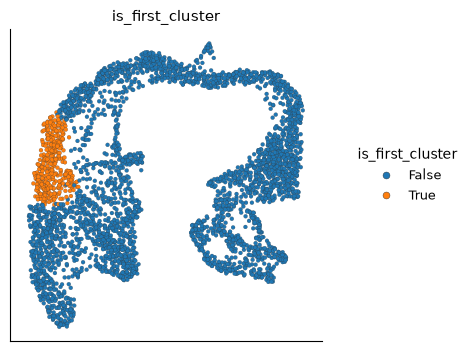

In [15]:
ds.plots.embedding(
    layout=analysis_run["umap"],
    color_by="is_first_cluster",
)

In [16]:
print(
    "fetch:", ds.cells.fetch("clusters", key="is_first_cluster").shape,
    "fetch_all:", ds.cells.fetch_all("clusters").shape,
)

fetch: (367,) fetch_all: (3696,)


In [17]:
active_before = int(ds.cells.fetch_all("I").sum())
count_range = ds.cells.sift(
    "RNA_nCounts",
    min_v=1000,
    max_v=15000,
)
joint_range = ds.cells.multi_sift(
    columns=["RNA_nCounts", "RNA_nFeatures"],
    lows=[1000, 500],
    highs=[15000, 4000],
)
ductal_rows = ds.cells.get_index_by(["Ductal"], "clusters")

print(
    "count_range:", int(count_range.sum()),
    "joint_range:", int(joint_range.sum()),
    "ductal_rows:", int(ductal_rows.size),
)
print("Active cells (I) before:", active_before)
print("Active cells (I) after:", int(ds.cells.fetch_all("I").sum()))

count_range: 3669 joint_range: 3667 ductal_rows: 916
Active cells (I) before: 3696
Active cells (I) after: 3696


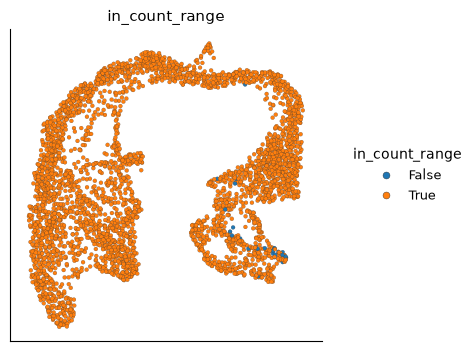

In [18]:
ds.cells.insert(column_name="in_count_range", values=count_range, overwrite=True)
ds.plots.embedding(
    layout=analysis_run["umap"],
    color_by="in_count_range",
)

In [19]:
print("Raw shape:", ds.RNA.rawData.shape)
print("Normed shape:", ds.RNA.normed().shape)
ds.RNA.rawData[:3, :5].compute()

Raw shape: (3696, 27998)
Normed shape: (3696, 27998)


array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]], dtype=uint16)

In [20]:
ds.RNA.normed()[:3, :5].compute()

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [21]:
reused_normalized = ds.run_normalization(
    analysis_run["analysis_cell_selection"],
    analysis_run["highly_variable_features"],
)
print("Reused:", reused_normalized == analysis_run["normalized"])
reused_normalized

Reused: True


ArtifactRef(assay='RNA', kind='normalized', artifact_id='1f04d6a47a0c...')

In [22]:
status = ds.inspect_artifact(reused_normalized)
print("Complete:", status.complete)
print("Operation:", status.operation)
print("Parameters:", status.parameters)

group = ds.load_artifact(reused_normalized)
print("Arrays:", list(group.array_keys())[:5])

Complete: True
Operation: run_normalization
Parameters: {'normalization_method': {'external_hook': True, 'module': 'scarf.assay', 'qualname': 'norm_lib_size'}, 'size_factor': 1000.0, 'log_transform': True, 'renormalize_subset': True}
Arrays: ['data', 'feature_squared_sum', 'feature_sum']


In [23]:
ds.get_markers(
    marker=marker_ref,
    group_id=cluster_values[0],
    min_score=0.1,
    min_frac_exp=0.1,
).head()

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,auc,p_value_adjusted
0,1,Gm2694,24369,0.42487,0.05704,0.00667,0.17711,0.03004,8.55746,1.469124e-39,0.57478,3.177549e-37
1,1,Blnk,11524,0.42134,0.05570,0.00687,0.22616,0.03935,8.10557,1.888118e-50,0.59601,7.661379e-48
2,1,Cyp4b1,16233,0.40204,0.06330,0.00906,0.24796,0.04716,6.99072,2.453198e-50,0.60275,9.673892e-48
3,1,Vdr,8144,0.39252,0.12453,0.02105,0.42779,0.09823,5.91719,4.486635e-78,0.67413,5.657971e-75
4,1,Slc25a35,4329,0.38984,0.03319,0.00235,0.14441,0.01382,14.09500,1.261251e-49,0.56578,4.904516e-47


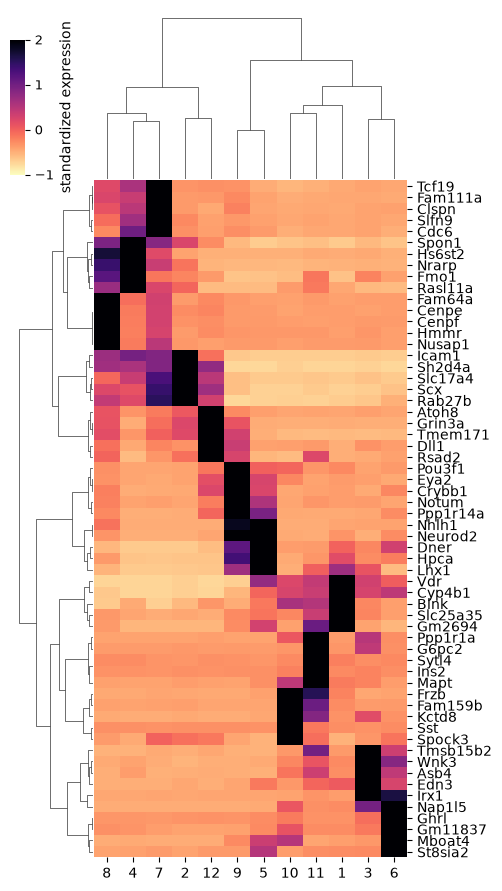

In [24]:
ds.plots.marker_heatmap(
    marker=marker_ref,
    topn=5,
    figsize=(5, 9),
)

In [25]:
markers_csv = "scarf_datasets/pancreas_cluster_markers.csv"
ds.export_markers_to_csv(
    marker=marker_ref,
    csv_filename=markers_csv,
    min_score=0.1,
    min_frac_exp=0.1,
)
pd.read_csv(markers_csv).iloc[:5, :6]

,1,10,11,12,2,3
0,Gm2694,Sst,Sytl4,Atoh8,Scx,Irx1
1,Blnk,Fam159b,Ins2,Grin3a,Slc17a4,Asb4
2,Cyp4b1,Kctd8,G6pc2,Dll1,Rab27b,Wnk3
3,Vdr,Frzb,Ppp1r1a,Rsad2,Icam1,Tmsb15b2
4,Slc25a35,Spock3,Mapt,Tmem171,Sh2d4a,Edn3
